In [63]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd
import time
# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

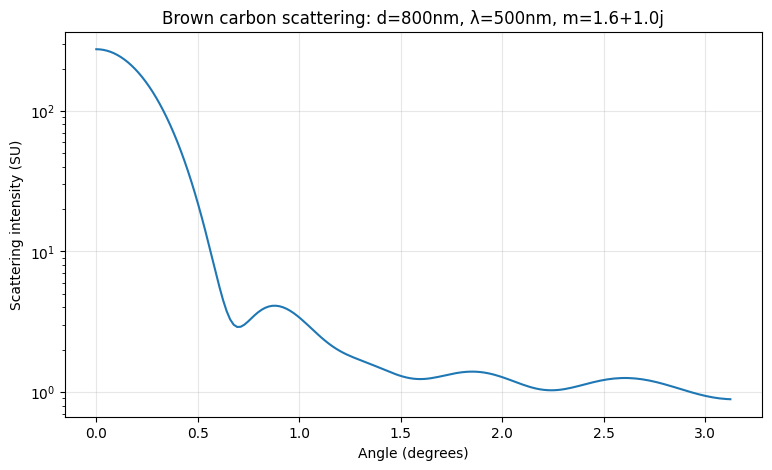

In [64]:
def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    return angle_scattering['i_unpol']

# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm
theta = torch.arange(0, 181) * torch.pi/181

scattering = py_Mie_Diff_Scattering(wavelength, diameter, n, k)

plt.figure(figsize=(9, 5))
plt.plot(theta, scattering)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
N_PARTICLES = 1000
N_ANGLES = 181

# Particle-level storage: shape (N_PARTICLES, N_ANGLES, ...)
particle_inputs = np.zeros((N_PARTICLES, N_ANGLES, 5)) # 5 params
particle_outputs = np.zeros((N_PARTICLES, N_ANGLES))
    # Reserve 5 slots for derivatives: [n, k, wavelength, diameter (placeholder), theta]
particle_derivatives = np.zeros((N_PARTICLES, N_ANGLES, 5)) # full jacobian storage (diameter kept as placeholder)

# The blueprint function: takes 5 normalized inputs, returns log scattering
def compute_log_scattering(wavelength_norm, diameter_norm, n_norm, k_norm, theta_norm):
    # Convert normalized to physical values
    wavelength = wavelength_norm * 100 + 450
    diameter   = diameter_norm * 300 + 600
    n          = n_norm * 0.36 + 1.5
    k          = k_norm * 0.32 + 0.68
    theta_rad  = theta_norm * torch.pi
    
    # pyMieDiff setup
    particle = pmd.Particle(
        r_layers=[diameter / 2],
        mat_layers=[n + 1j * k],     # tensor-based complex (preserves gradients)
        mat_env=1.00
    )

    k0 = 2 * torch.pi / wavelength
    
    scattering = particle.get_angular_scattering(k0=k0, theta=theta_rad)
    return torch.log10(scattering['i_unpol'])

print("Particle setup complete.")
print(f"Storage allocated for {N_PARTICLES} particles × {N_ANGLES} angles × 5 params")


Particle setup complete.
Storage allocated for 1000 particles × 181 angles × 5 params


Generating 1000 particles with jacobians...
  particle 0/1000  (0.2s elapsed)
  particle 25/1000  (5.4s elapsed)
  particle 50/1000  (11.3s elapsed)
  particle 75/1000  (17.3s elapsed)
  particle 100/1000  (23.4s elapsed)
  particle 125/1000  (29.5s elapsed)
  particle 150/1000  (35.6s elapsed)
  particle 175/1000  (41.6s elapsed)
  particle 200/1000  (47.7s elapsed)
  particle 225/1000  (53.8s elapsed)
  particle 250/1000  (60.0s elapsed)
  particle 275/1000  (66.1s elapsed)
  particle 300/1000  (72.2s elapsed)
  particle 325/1000  (78.4s elapsed)
  particle 350/1000  (84.4s elapsed)
  particle 375/1000  (90.5s elapsed)
  particle 400/1000  (96.6s elapsed)
  particle 425/1000  (102.6s elapsed)
  particle 450/1000  (108.6s elapsed)
  particle 475/1000  (114.6s elapsed)
  particle 500/1000  (120.6s elapsed)
  particle 525/1000  (126.5s elapsed)
  particle 550/1000  (132.5s elapsed)
  particle 575/1000  (138.6s elapsed)
  particle 600/1000  (144.6s elapsed)
  particle 625/1000  (150.7s e

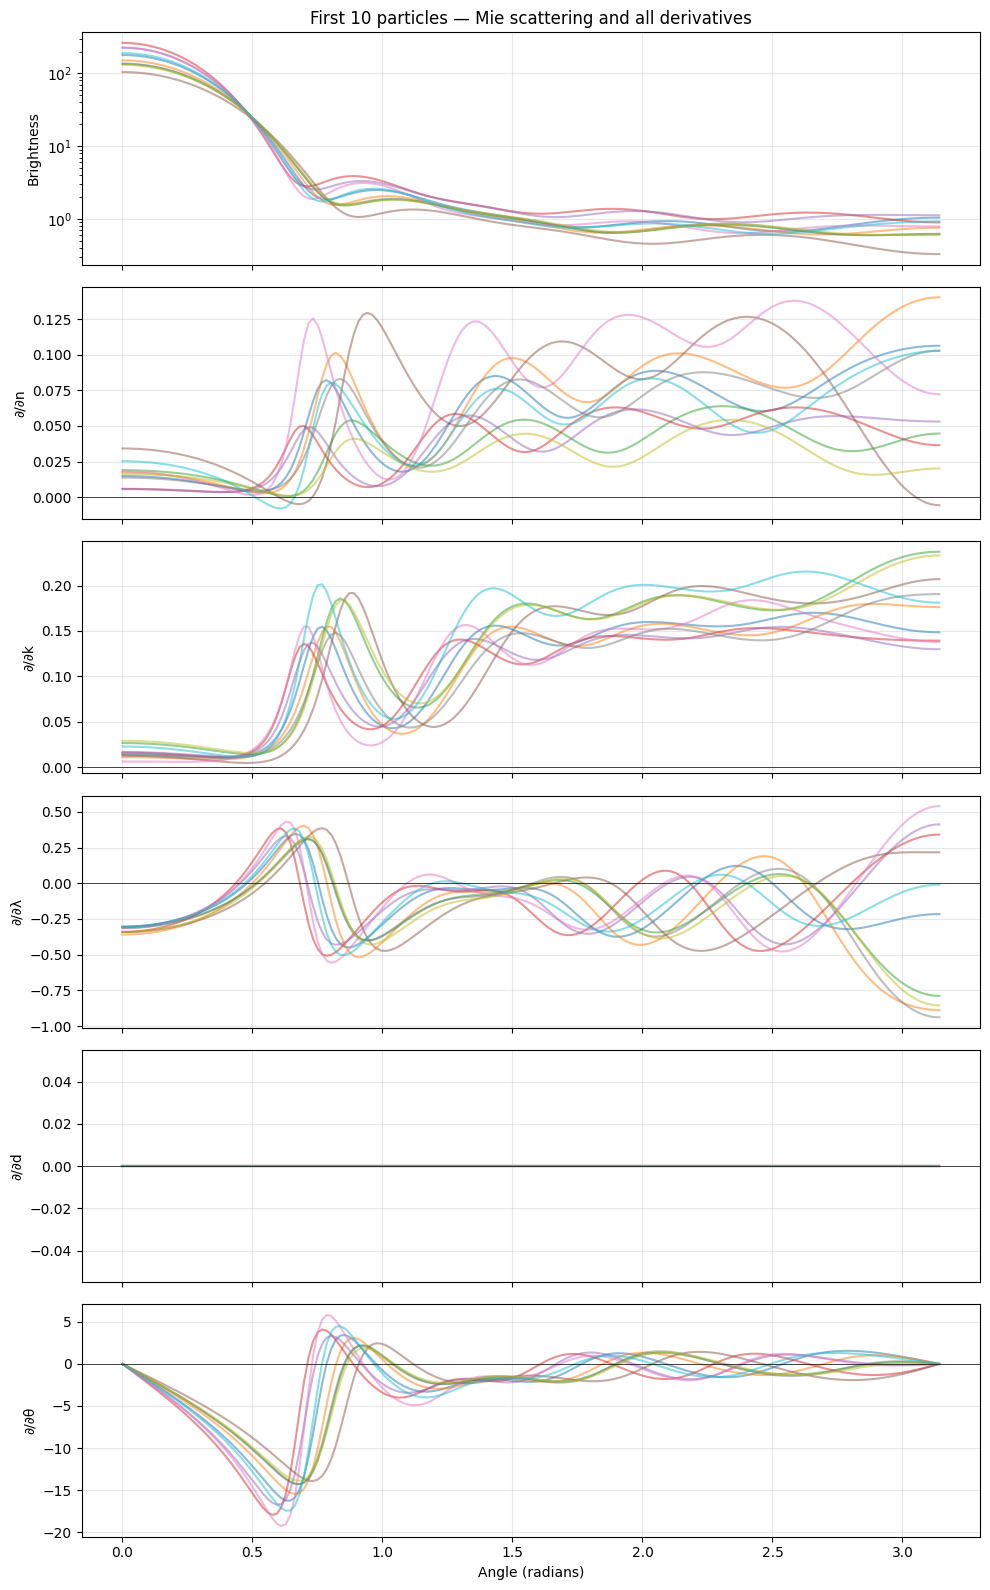

In [74]:
print(f"Generating {N_PARTICLES} particles with jacobians...")

fig, axes = plt.subplots(6, 1, figsize=(10, 16), sharex=True)

start_time = time.time()
for p in range(N_PARTICLES):
    wavelength_norm = torch.tensor(np.random.uniform(0, 1))
    diameter_norm   = torch.tensor(np.random.uniform(0, 1))
    n_norm          = torch.tensor(np.random.uniform(0, 1))
    k_norm          = torch.tensor(np.random.uniform(0, 1))
    theta_norm      = torch.tensor(np.linspace(0, 1, N_ANGLES))  # 0 to 1 maps to 0 to 180

    # Compute jacobian derivatives with autograd
    # jacobian wraps inputs with gradient tracking
    jacobian_derivative = torch.autograd.functional.jacobian(
        compute_log_scattering,
        (wavelength_norm, diameter_norm, n_norm, k_norm, theta_norm),
        vectorize=True
    )

    # compute actual values without gradients for storage
    with torch.no_grad():
        log_scattering = compute_log_scattering(wavelength_norm, diameter_norm, n_norm, k_norm, theta_norm)
        scattering = 10 ** log_scattering
    
     # Convert normalized to physics values for storage
    wavelength_val = wavelength_norm.item() * 100 + 450
    diameter_val   = diameter_norm.item() * 300 + 600
    n_val          = n_norm.item() * 0.36 + 1.5
    k_val          = k_norm.item() * 0.32 + 0.68
    
    # Store inputs
    particle_inputs[p, :, 0] = n_val
    particle_inputs[p, :, 1] = k_val
    particle_inputs[p, :, 2] = wavelength_val
    particle_inputs[p, :, 3] = diameter_val
    particle_inputs[p, :, 4] = theta_norm.numpy() * np.pi
    
    # Store outputs
    particle_outputs[p, :] = scattering.numpy()
    
    # Store derivatives
    particle_derivatives[p, :, 0] = jacobian_derivative[2].numpy()           # delta scattering/delta n
    particle_derivatives[p, :, 1] = jacobian_derivative[3].numpy()           # delta scattering/delta k
    particle_derivatives[p, :, 2] = jacobian_derivative[0].numpy()           # delta scattering/delta wavelength
    # Diameter gradient usually zero in pyMieDiff autograd — keep placeholder zeros
    particle_derivatives[p, :, 3] = jacobian_derivative[1].numpy()           # delta scattering/delta diameter (placeholder, often zero)
    # Theta derivative: place in column 4
    particle_derivatives[p, :, 4] = jacobian_derivative[4].diag().numpy()    # delta scattering/delta theta (diagonal)
    
    # For the first 10 particles, plot the scattering and all derivatives
    if p < 10:
        angles = theta_norm.numpy() * np.pi
        axes[0].plot(angles, scattering.numpy(), alpha=0.5)
        axes[1].plot(angles, jacobian_derivative[2].numpy(), alpha=0.5)    # ∂/∂n
        axes[2].plot(angles, jacobian_derivative[3].numpy(), alpha=0.5)    # ∂/∂k
        axes[3].plot(angles, jacobian_derivative[0].numpy(), alpha=0.5)    # ∂/∂wavelength
        axes[4].plot(angles, jacobian_derivative[1].numpy(), alpha=0.5)    # ∂/∂diameter
        axes[5].plot(angles, jacobian_derivative[4].diag().numpy(), alpha=0.5)   # ∂/∂theta

    if p % 25 == 0:
        elapsed = time.time() - start_time
        print(f"  particle {p}/{N_PARTICLES}  ({elapsed:.1f}s elapsed)")

total_time = time.time() - start_time
print(f"\nDone! Total time: {total_time:.1f}s ({total_time/N_PARTICLES:.2f}s per particle)")

# After the loop:
axes[0].set_ylabel('Brightness')
axes[0].set_title('First 10 particles — Mie scattering and all derivatives')
axes[0].set_yscale('log')
axes[1].set_ylabel('∂/∂n')
axes[2].set_ylabel('∂/∂k')
axes[3].set_ylabel('∂/∂λ')
axes[4].set_ylabel('∂/∂d') # prints out nothin so diameter is broken in pyMieDiff autograd
axes[5].set_ylabel('∂/∂θ')
axes[5].set_xlabel('Angle (radians)')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# flatten particle data for training
inputs = particle_inputs.reshape(-1, 5)         # (181000, 5)
outputs = particle_outputs.reshape(-1, 1)       # (181000, 1)
derivatives = particle_derivatives.reshape(-1, 5) # (181000, 5)  ← changed: -1, 5

N_SAMPLES = inputs.shape[0] # num of rows in inputs

# log transform the outputs
log_outputs = np.log10(outputs)

# normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 1.5) / (1.86 - 1.5)        # n
inputs_norm[:, 1] = (inputs[:, 1] - 0.68) / (1.00 - 0.68)      # k
inputs_norm[:, 2] = (inputs[:, 2] - 450) / 100                  # wavelength
inputs_norm[:, 3] = (inputs[:, 3] - 600) / 300                  # diameter
inputs_norm[:, 4] = inputs[:, 4] / np.pi

# train/test split 80 percent train, 20 percent test
n_train = int(0.8 * N_SAMPLES)

X_train = torch.FloatTensor(inputs_norm[:n_train])
y_train = torch.FloatTensor(log_outputs[:n_train])
dy_train = torch.FloatTensor(derivatives[:n_train]) # for loss function

X_test = torch.FloatTensor(inputs_norm[n_train:])
y_test = torch.FloatTensor(log_outputs[n_train:])
dy_test = torch.FloatTensor(derivatives[n_train:])

print(f"Shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}, dy_train: {dy_train.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}, dy_test:  {dy_test.shape}")
print()
print(f"Sample input (normalized): {X_train[0]}")
print(f"Sample output (log): {y_train[0]}")
print(f"Sample derivative (truth): {dy_train[0]}")


Shapes:
  X_train: torch.Size([144800, 5]), y_train: torch.Size([144800, 1]), dy_train: torch.Size([144800, 4])
  X_test:  torch.Size([36200, 5]), y_test:  torch.Size([36200, 1]), dy_test:  torch.Size([81450, 4])

Sample input (normalized): tensor([0.5639, 0.5003, 0.8904, 0.5769, 0.0000])
Sample output (log): tensor([2.2529])
Sample derivative (truth): tensor([ 0.0148,  0.0141, -0.3041,  0.0000])


In [76]:
model = nn.Sequential(
    nn.Linear(5, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 128 to 256
    nn.GELU(),
    nn.Linear(256, 128),    # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(128,1)
    
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=5, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 66817


In [77]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [78]:
N_EPOCHS = 200
BATCH_SIZE = 256
derivative_normalization = 0.01

train_losses = []
test_losses = []
n_train = X_train.shape[0]
n_batches = n_train // BATCH_SIZE


# def determine_derivative()
print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")
training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    dy_shuffled = dy_train[perm] # shuffle the derivatives the same way

    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0

    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end].clone().requires_grad_(True) # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        dy_batch = dy_shuffled[start:end]

        # forward pass
        pred = model(X_batch)

        # take jacobian derivative of prediction wrt all 5 inputs
        nn_derivative = torch.autograd.grad(pred.sum(), (X_batch), create_graph=True)[0]

        # When computing derivative loss, skip diameter (column 3)
        useful_cols = [0, 1, 2, 4]   # n, k, wavelength, theta
        loss_derivative = loss_fn(
            nn_derivative[:, useful_cols],   # 4 columns of NN derivatives
            dy_batch[:, useful_cols]          # 4 columns of truth derivatives
        )
        print(nn_derivative[:, useful_cols])
        print(dy_batch[:, useful_cols].shape)
        # loss terms
        loss_intensity = loss_fn(pred, y_batch) # get the loss for brightness
    
        loss = loss_intensity + derivative_normalization * (loss_derivative) # total loss is intensity loss + derivative loss (scaled down)

        # back propogate
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    

    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    X_test_req = X_test.detach().clone().requires_grad_(True) # this way the original X_test doesn't have to carry around it's claculation history
    test_pred = model(X_test_req) #predict on 200 test examples
    test_nn_derivative = torch.autograd.grad(test_pred.sum(), X_test_req, create_graph=False)[0] # derivative with respect to training parameters
    print(f"dy_test shape: {dy_test.shape}")
    print(f"dy_test first 3 rows: {dy_test[:3]}")
    print(f"test_nn_derivative shape: {test_nn_derivative.shape}")
    print(f"test_nn_derivative first 3 rows: {test_nn_derivative[:3]}")
    print(f"derivatives shape: {derivatives.shape}")
    print(f"n_train: {n_train}")
    print(f"N_SAMPLES: {N_SAMPLES}")
    print(f"inputs shape: {inputs.shape}")
    print(f"outputs shape: {outputs.shape}")
    test_loss_intensity = loss_fn(test_pred, y_test).item() #compute MSE on test set
    useful_cols = [0, 1, 2, 4]
    test_loss_derivative = loss_fn(test_nn_derivative[:, useful_cols], dy_test[:, useful_cols]).item() # compute MSE on derivative (skip diameter)
    test_loss = test_loss_intensity + derivative_normalization * test_loss_derivative
    test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")

Training: 200 epochs, 565 batches per epoch



IndexError: index 4 is out of bounds for dimension 0 with size 4

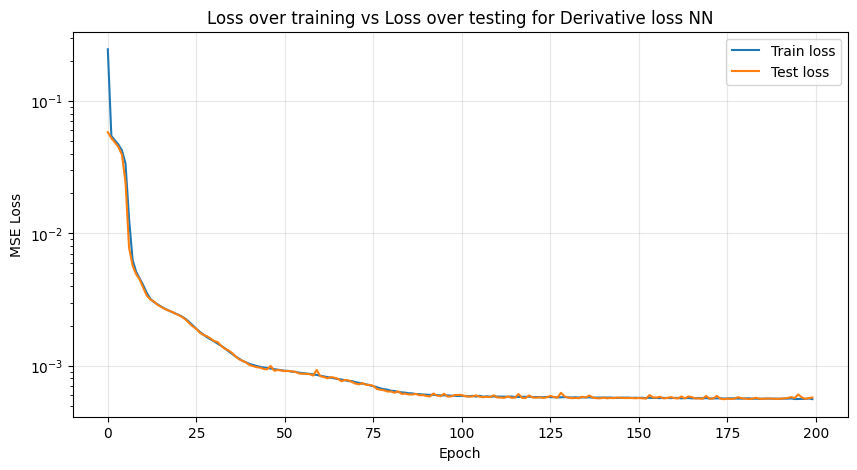

X_train shape: torch.Size([144800, 5])
y_train shape: torch.Size([144800, 1])
y_train min: -0.5315
y_train max: 2.7994
y_train mean: 0.4228
y_train variance: 0.5874

Final train loss: 0.0006
Final test loss: 0.0006


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing for Derivative loss NN")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min().item():.4f}")
print(f"y_train max: {y_train.max().item():.4f}")
print(f"y_train mean: {y_train.mean().item():.4f}")
print(f"y_train variance: {y_train.var().item():.4f}")
print()
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")